In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.signal import convolve2d
from scipy.optimize import curve_fit
from scipy import fft

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


constant definition

In [2]:
dx = 10e-6
dt = 3.65e-6
phiQ = 2.06e-15
gamma = 28e9

In [3]:
plt.rcParams.update({'font.size': 28})
plt.rcParams.update({'lines.linewidth': 3})

def findMoment(arr,order,shift=0):
    # Shift i to i - 50
    shifted_indices = np.arange(len(arr)) - (len(arr)/2) - shift
    
    zero = np.average(arr[0:10])

    # return np.sum(shifted_indices**order * (arr-np.min(arr))) / np.sum(arr-np.min(arr))
    # return np.sum(shifted_indices**order * (np.abs(arr-zero)) / np.sum(np.abs(arr-zero)))
    return np.sum(shifted_indices**order * (arr-zero) / np.sum(np.abs(arr-zero)))

def gaussian_2d(coor, x0, y0, sigma_x, sigma_y, amplitude, offset):
    """2D Gaussian function."""
    x = coor[0]
    y = coor[1]
    return offset + amplitude * np.exp(
        -(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2))
    )

## Correlation Rnd Diagonal Hopping Interaction

100\*100\*300, dx=1 um, 

J = 0.03 A/m, R = 1.2e14  id = 23

J = 0.1 A/m, R = 1.0e16 id = 30

load data

In [4]:
# the format is ../data/250629/250629_<id>_
file_name = "../data/250629/250629_30_"
x_l = np.loadtxt(file_name+'pcoor_scanx.csv',skiprows=1)
y_l = np.loadtxt(file_name+'pcoor_scany.csv',skiprows=1)
t_l = np.loadtxt(file_name+'pcoor_scanz.csv',skiprows=1)
raw = np.loadtxt(file_name+'pcoor_data.csv',skiprows=1,delimiter=',')
pcoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
raw = np.loadtxt(file_name+'ncoor_data.csv',skiprows=1,delimiter=',')
ncoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
raw = np.loadtxt(file_name+'scoor_data.csv',skiprows=1,delimiter=',')
scoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')

mid_lattice = int(len(x_l)/2)

plot correlation at fixed time slices
first row 

1009326.0200000001


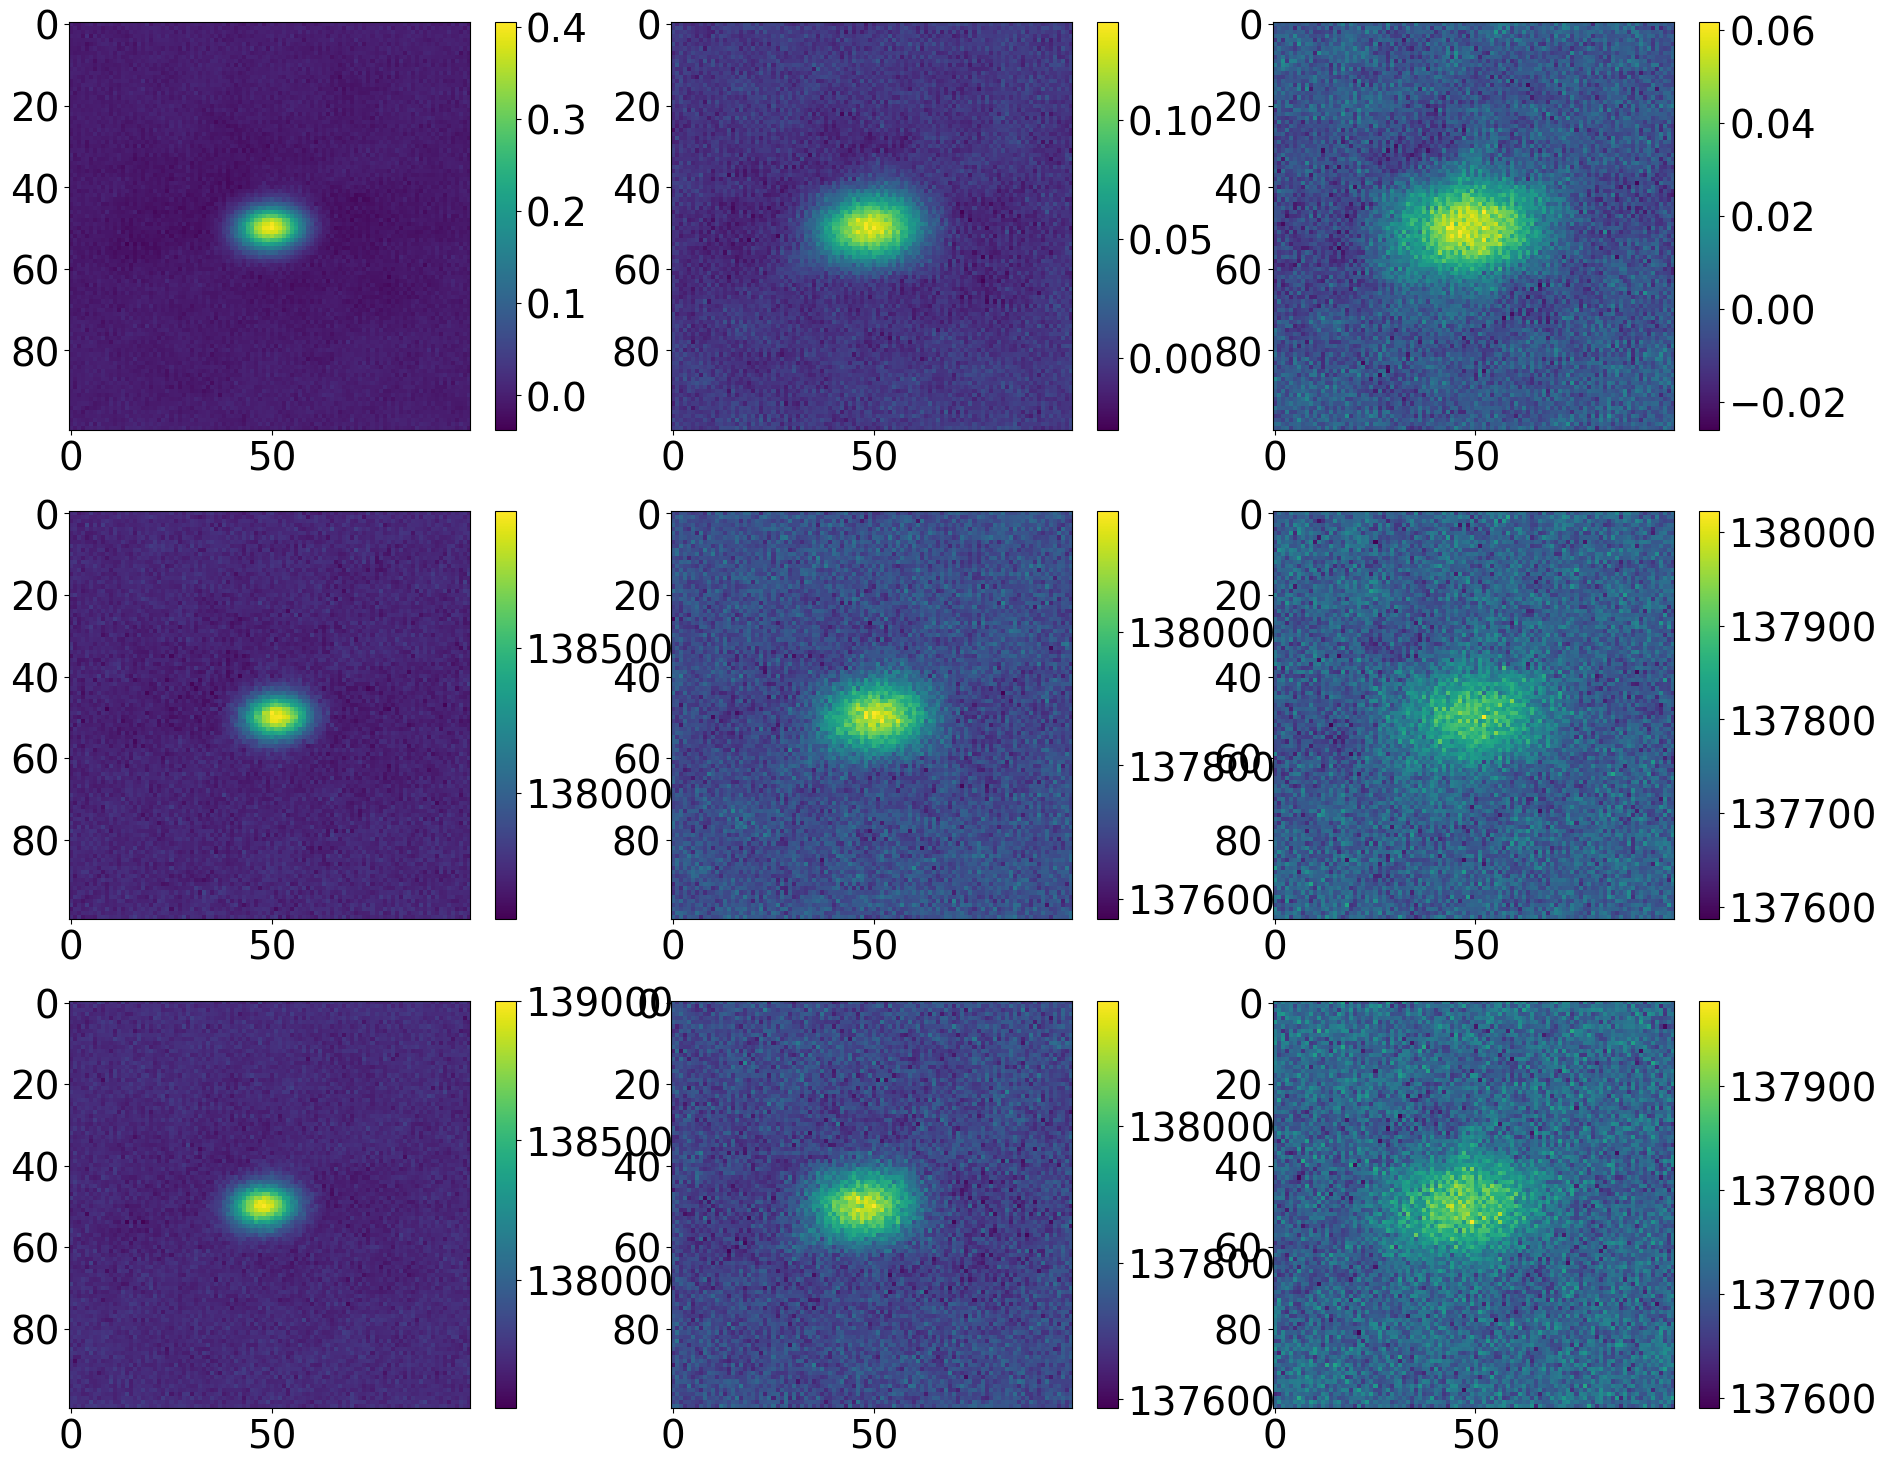

In [5]:
# three time slices to plot the correlation
t1 = 20
t2 = 50
t3 = 100

plt.figure(figsize=(22,18))
plt.subplot(3,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,4)
pcoor_r = np.roll(pcoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,5)
pcoor_r = np.roll(pcoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,6)
pcoor_r = np.roll(pcoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,7)
ncoor_r = np.roll(ncoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,8)
ncoor_r = np.roll(ncoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,9)
ncoor_r = np.roll(ncoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()

print(np.max(scoor[:,:,0]))

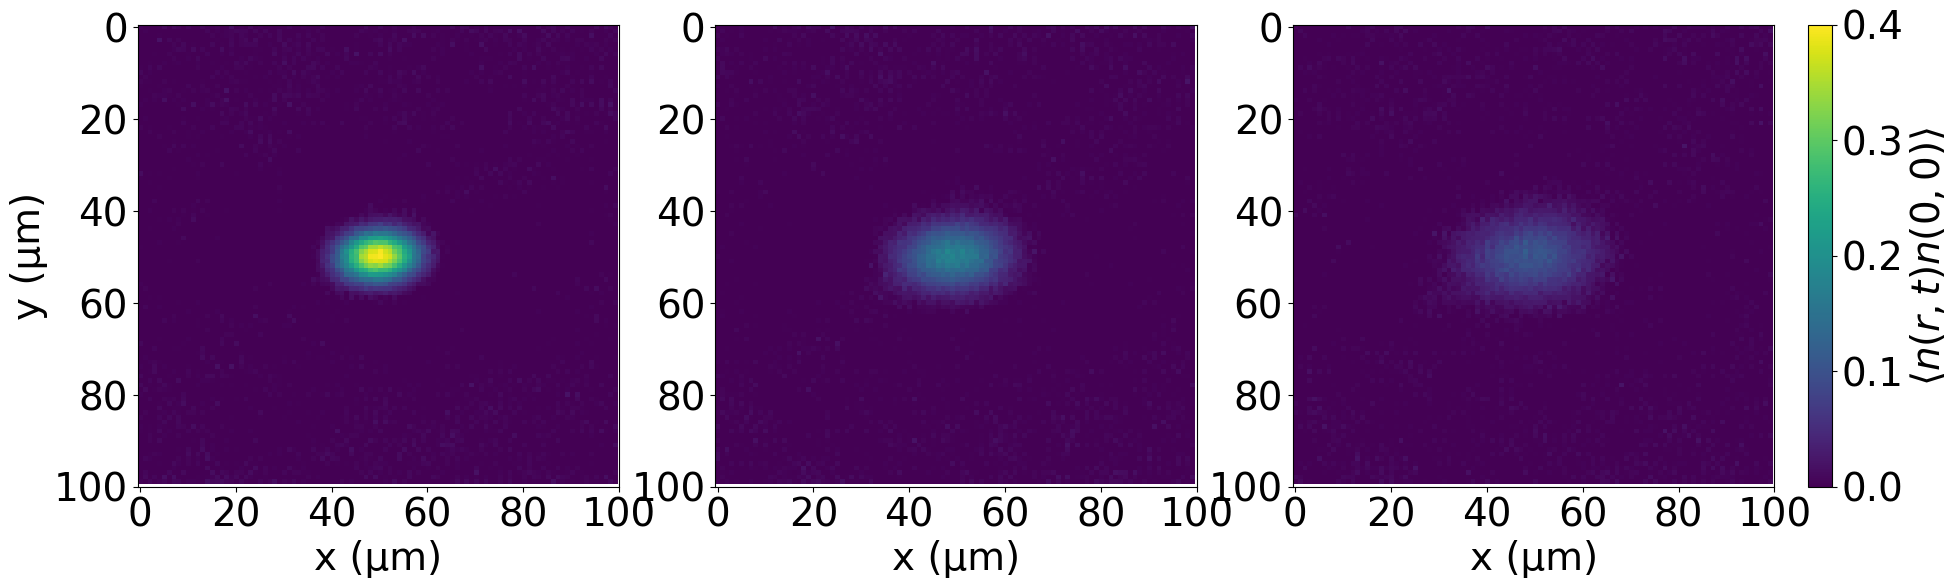

In [6]:
t1 = 20
t2 = 40
t3 = 60

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
vmin, vmax = 0, 0.4
xticks = yticks = [0, 20, 40, 60, 80, 100]

scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im0 = axes[0].imshow(scoor_r/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax)
axes[0].set_xticks(xticks)
axes[0].set_yticks(yticks)
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im1 = axes[1].imshow(scoor_r/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax)
axes[1].set_xticks(xticks)
axes[1].set_yticks(yticks)
axes[1].set_xlabel('x (μm)')
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im2 = axes[2].imshow(scoor_r/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax)
axes[2].set_xticks(xticks)
axes[2].set_yticks(yticks)
axes[2].set_xlabel('x (μm)')

# Shared colorbar
cbar = fig.colorbar(im0, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r'$\langle n(r,t)n(0,0) \rangle$')
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4])

# plt.tight_layout()


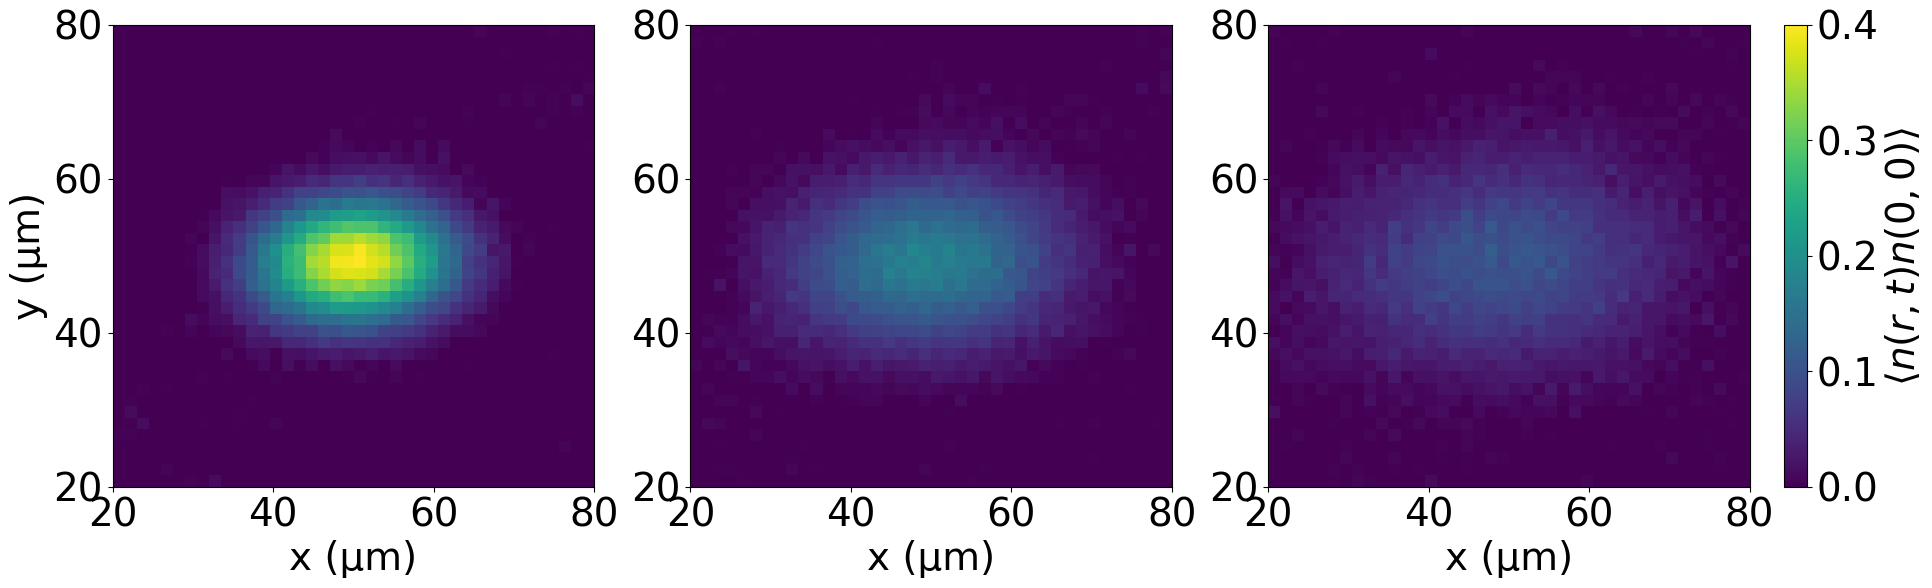

In [7]:
# Zoomed-in view from 20 to 80 in both directions
plt.rcParams.update({'font.size': 28})
t1 = 20
t2 = 40
t3 = 60

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
vmin, vmax = 0, 0.4
# xticks = yticks = [20, 30, 40, 50, 60, 70, 80]
# xticks = yticks = [30, 50, 70]

# Zoom to region [20:80, 20:80]
zoom_slice = slice(30, 70)

scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im0 = axes[0].imshow(scoor_r[zoom_slice, zoom_slice]/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax, extent=[20, 80, 20, 80])
# axes[0].set_xticks(xticks)
# axes[0].set_yticks(yticks)
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')

scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im1 = axes[1].imshow(scoor_r[zoom_slice, zoom_slice]/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax, extent=[20, 80, 20, 80])
# axes[1].set_xticks(xticks)
# axes[1].set_yticks(yticks)
axes[1].set_xlabel('x (μm)')

scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
im2 = axes[2].imshow(scoor_r[zoom_slice, zoom_slice]/np.max(scoor[:,:,10]), aspect='auto', vmin=vmin, vmax=vmax, extent=[20, 80, 20, 80])
# axes[2].set_xticks(xticks)
# axes[2].set_yticks(yticks)
axes[2].set_xlabel('x (μm)')

# Shared colorbar
cbar = fig.colorbar(im0, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r'$\langle n(r,t)n(0,0) \rangle$')
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4])

# plt.tight_layout()
# plt.show()

In [20]:
# Export all data needed to reproduce the zoomed profile plot (cell 11)
import os

paper_plot_dir = "paper_plot"
os.makedirs(paper_plot_dir, exist_ok=True)

# Parameters from the plotting cell
zoom_start, zoom_end = 30, 70
zoom_slice = slice(zoom_start, zoom_end)
t_indices = np.array([t1, t2, t3], dtype=int)
extent = np.array([20, 80, 20, 80], dtype=float)
cbar_ticks = np.array([0, 0.1, 0.2, 0.3, 0.4], dtype=float)

norm_ref = np.max(scoor[:, :, 10])
images = []
for t_idx in t_indices:
    scoor_r = np.roll(scoor[:, :, t_idx], (int(len(x_l) / 2), int(len(y_l) / 2)), (0, 1))
    images.append(scoor_r[zoom_slice, zoom_slice] / norm_ref)
images = np.stack(images, axis=0)

np.savez(
    os.path.join(paper_plot_dir, "profile_plot_data.npz"),
    images=images,
    t_indices=t_indices,
    extent=extent,
    vmin=np.array(0.0),
    vmax=np.array(0.4),
    cbar_ticks=cbar_ticks,
    cbar_label=np.array(r"$\\langle n(r,t)n(0,0) \\rangle$"),
    xlabel=np.array("x (μm)"),
    ylabel=np.array("y (μm)"),
    figsize=np.array([22.0, 6.0]),
    zoom_bounds=np.array([zoom_start, zoom_end], dtype=int),
)

print("Exported plot data to paper_plot/profile_plot_data.npz")

Exported plot data to paper_plot/profile_plot_data.npz


### Fit Gaussian

In [8]:
params_l = []
# for t in range(int(scoor.shape[-1]/2)):
for t in range(100):
    scoor_t = np.roll(scoor[:,:,t],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
    # Get the coordinates of the pixels
    x = np.arange(0, scoor_t.shape[1])
    y = np.arange(0, scoor_t.shape[0])
    x, y = np.meshgrid(x, y)

    # Flatten the arrays for fitting
    x = x.ravel()
    y = y.ravel()
    z = scoor_t.ravel()

    # Initial guess for the parameters
    initial_guess = (scoor_t.shape[1] / 2, scoor_t.shape[0] / 2, 1, 1, np.max(scoor_t), np.min(scoor_t))
    
    # Fit the data
    params, _ = curve_fit(gaussian_2d, (x, y), z, p0=initial_guess)

    # Extract the parameters
    x0, y0, sigma_x, sigma_y, amplitude, offset = params
    params_l.append(params)

params_l = np.array(params_l)
params_l.shape

/Users/frankzhang/anaconda3/envs/ece396_2024/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


(100, 6)

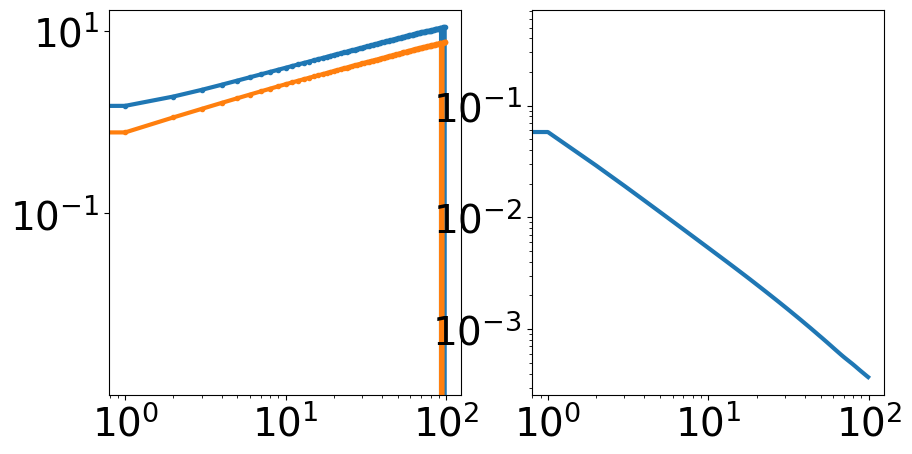

In [9]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(params_l[:,2],'.-')
plt.plot(params_l[:,3],'.-')
# plt.ylim(1e0,1e1)
plt.xscale('log')
plt.yscale('log')
plt.subplot(1,2,2)
plt.plot(params_l[:,4]/(200*100*100))
plt.xscale('log')
plt.yscale('log')

In [10]:
slope_start = 10
slope_end = 100

# tfit_l = np.arange(slope_start,slope_end,dtype=int)
# m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,2]), 1)
# print("var exponents", m, "base", b)
# m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,3]), 1)
# print("var exponents", m, "base", b)
# m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,4]), 1)
# print("var exponents", m)

/var/folders/d0/tvg6bvm9377bmz53zj2vwnf00000gn/T/ipykernel_80519/2097938763.py:5: RuntimeWarning: invalid value encountered in log
  m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,2]), 1)


** On entry to DGELSD, parameter number  6 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

### Estimate noise

In [11]:
Bcorr = scoor / (300*100*100) * ((phiQ/dx**2)**2)

T2 = 100e-6

depth = 1e-7

Bcorr_fft = fft.fftn(Bcorr,axes=(0,1))

kx = np.roll(np.linspace(-np.pi, np.pi, Bcorr.shape[0]),int(Bcorr.shape[0]/2))
ky = np.roll(np.linspace(-np.pi, np.pi, Bcorr.shape[1]),int(Bcorr.shape[1]/2))
# x = np.arange(-int(Bcorr.shape[0]/2), int(Bcorr.shape[0]/2), 1)
# y = np.arange(-int(Bcorr.shape[1]/2), int(Bcorr.shape[1]/2), 1)
kxx, kyy = np.meshgrid(kx, ky)
kz = np.sqrt(kxx**2 + kyy**2)
kz_repeat = np.repeat(kz[:, :, np.newaxis], Bcorr.shape[2], axis=2)
Bcorr_fft_prop = Bcorr_fft * np.exp(-2*kz_repeat*(depth/dx))

Bcorr_prop = fft.ifftn(Bcorr_fft_prop,axes=(0,1))

noise = np.sum(Bcorr_prop[10,0,0:min(int(T2/dt),Bcorr_prop.shape[2])])*dt
print(noise)

noise = np.sum(Bcorr_prop[0,10,0:min(int(T2/dt),Bcorr_prop.shape[2])])*dt
print(noise)

(-1.0528381381260563e-18-2.924036605028323e-21j)
(3.2178983545842727e-18-7.81774873305201e-21j)


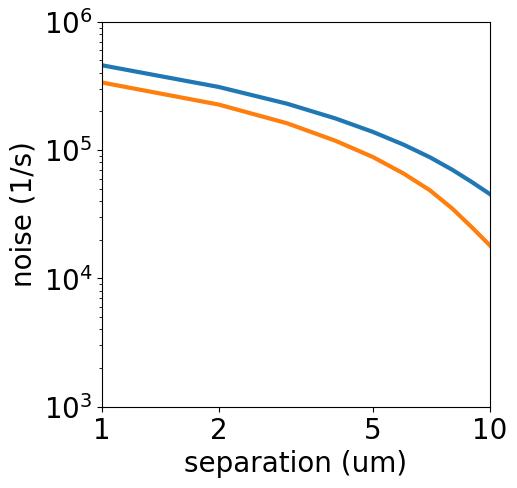

In [12]:
pnoise_l = []
vnoise_l = []

for i in range(50):
    # pnoise_l.append(np.sum(Bcorr_prop[0,i,0:min(int(T2/dt),Bcorr_prop.shape[2])])*dt)
    # vnoise_l.append(np.sum(Bcorr_prop[i,0,0:min(int(T2/dt),Bcorr_prop.shape[2])])*dt)
    pnoise_l.append(np.sum(Bcorr_prop[0,i,:])*np.exp(-i*dt/T2)*dt)
    vnoise_l.append(np.sum(Bcorr_prop[i,0,:])*np.exp(-i*dt/T2)*dt)

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(5,5))
plt.plot(np.arange(50)*1, gamma**2*np.abs(pnoise_l))
plt.plot(np.arange(50)*1, gamma**2*np.abs(vnoise_l))
plt.xscale('log')
plt.yscale('log')
plt.xlim(1,10)
plt.ylim(1e3,1e6)
plt.xlabel('separation (um)')
plt.ylabel('noise (1/s)')
ax = plt.gca()
xticks = np.array([1, 2, 5, 10])
ax.set_xticks(xticks)
ax.set_xticklabels(['1', '2','5', '10'])
ax.xaxis.set_minor_locator(plt.NullLocator())

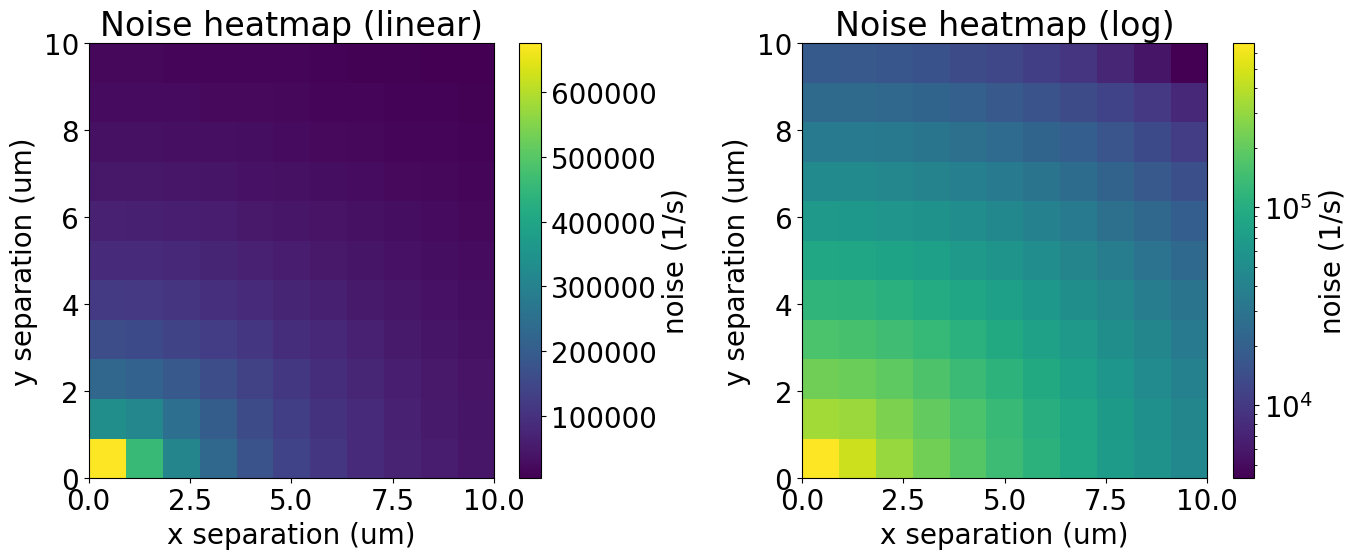

In [27]:
# 2D heatmap of noise for x,y in [0, 50] using i = sqrt(x^2 + y^2)
# noise2d[x,y] = gamma^2 * |sum_t Bcorr_prop[x,y,t] * exp(-i*dt/T2) * dt|

max_idx = 10
x_idx = np.arange(max_idx + 1)
y_idx = np.arange(max_idx + 1)

x_grid, y_grid = np.meshgrid(x_idx, y_idx, indexing='ij')
i_grid = np.sqrt(x_grid**2 + y_grid**2)

corr_slice = Bcorr_prop[:max_idx + 1, :max_idx + 1, :]
weight = np.exp(-(i_grid[:, :, np.newaxis] * dt / T2))
noise2d = gamma**2 * np.abs(np.sum(corr_slice * weight, axis=2) * dt)

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(
    noise2d,
    origin='lower',
    extent=[0, max_idx, 0, max_idx],
    aspect='auto',
)
axes[0].set_xlabel('x separation (um)')
axes[0].set_ylabel('y separation (um)')
axes[0].set_title('Noise heatmap (linear)')
fig.colorbar(im0, ax=axes[0], label='noise (1/s)')

im1 = axes[1].imshow(
    noise2d,
    origin='lower',
    extent=[0, max_idx, 0, max_idx],
    aspect='auto',
    norm=plt.matplotlib.colors.LogNorm(vmin=max(np.min(noise2d[noise2d > 0]), 1e-12), vmax=np.max(noise2d)),
)
axes[1].set_xlabel('x separation (um)')
axes[1].set_ylabel('y separation (um)')
axes[1].set_title('Noise heatmap (log)')
fig.colorbar(im1, ax=axes[1], label='noise (1/s)')

plt.tight_layout()
plt.show()

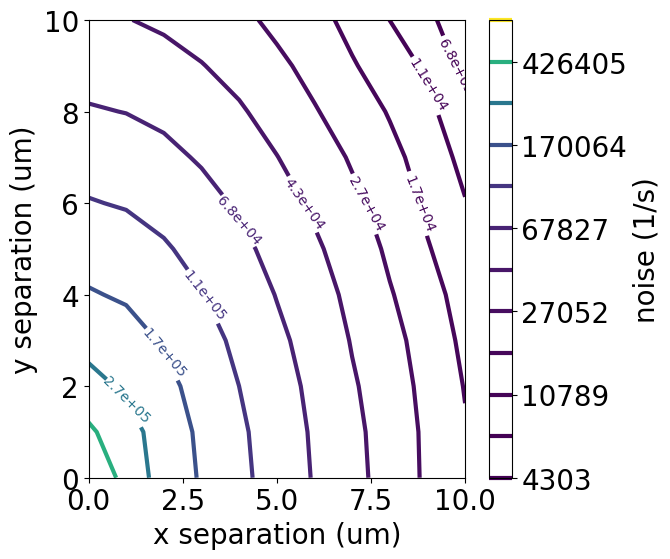

In [ ]:
# Equal-value contour plot from the same 2D noise map
# Uses log-spaced contour levels in noise (1/s)

X, Y = np.meshgrid(x_idx, y_idx, indexing='ij')

positive = noise2d[noise2d > 0]
vmin_c = np.min(positive)
vmax_c = np.max(positive)
levels = np.logspace(np.log10(vmin_c), np.log10(vmax_c), 12)

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(7, 6))

cs = plt.contour(X, Y, noise2d, levels=levels, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=10, fmt='%.1e')

plt.xlim(0, max_idx)
plt.ylim(0, max_idx)
plt.xlabel('x separation (um)')
plt.ylabel('y separation (um)')
plt.title('Equal-value contours of noise (1/s)')

cbar = plt.colorbar(cs)
cbar.set_label('noise (1/s)')

plt.tight_layout()
plt.show()

In [30]:
# Export all data needed to reproduce the 2D_countour plot (cell 21)
import os

paper_plot_dir = "paper_plot"
os.makedirs(paper_plot_dir, exist_ok=True)

np.savez(
    os.path.join(paper_plot_dir, "2D_countour_data.npz"),
    X=np.array(X),
    Y=np.array(Y),
    noise2d=np.array(noise2d),
    levels=np.array(levels),
    max_idx=np.array(max_idx),
    xlabel=np.array("x separation (um)"),
    ylabel=np.array("y separation (um)"),
    title=np.array("Equal-value contours of noise (1/s)"),
    cbar_label=np.array("noise (1/s)"),
    figsize=np.array([7.0, 6.0]),
    label_fontsize=np.array(10),
)

print("Exported plot data to paper_plot/2D_countour_data.npz")

Exported plot data to paper_plot/2D_countour_data.npz


In [21]:
# Export all data needed to reproduce the noise-vs-separation plot (cell 19)
import os

paper_plot_dir = "paper_plot"
os.makedirs(paper_plot_dir, exist_ok=True)

separation = np.arange(50, dtype=float)
pnoise_plot = gamma**2 * np.abs(np.array(pnoise_l))
vnoise_plot = gamma**2 * np.abs(np.array(vnoise_l))

np.savez(
    os.path.join(paper_plot_dir, "noise_vs_separation_data.npz"),
    separation=separation,
    pnoise_plot=pnoise_plot,
    vnoise_plot=vnoise_plot,
    xscale=np.array("log"),
    yscale=np.array("log"),
    xlim=np.array([1.0, 10.0]),
    ylim=np.array([1e3, 1e6]),
    xlabel=np.array("separation (um)"),
    ylabel=np.array("noise (1/s)"),
    xticks=np.array([1, 2, 5, 10], dtype=float),
    xtick_labels=np.array(["1", "2", "5", "10"]),
    figsize=np.array([5.0, 5.0]),
    font_size=np.array(20),
)

print("Exported plot data to paper_plot/noise_vs_separation_data.npz")

Exported plot data to paper_plot/noise_vs_separation_data.npz


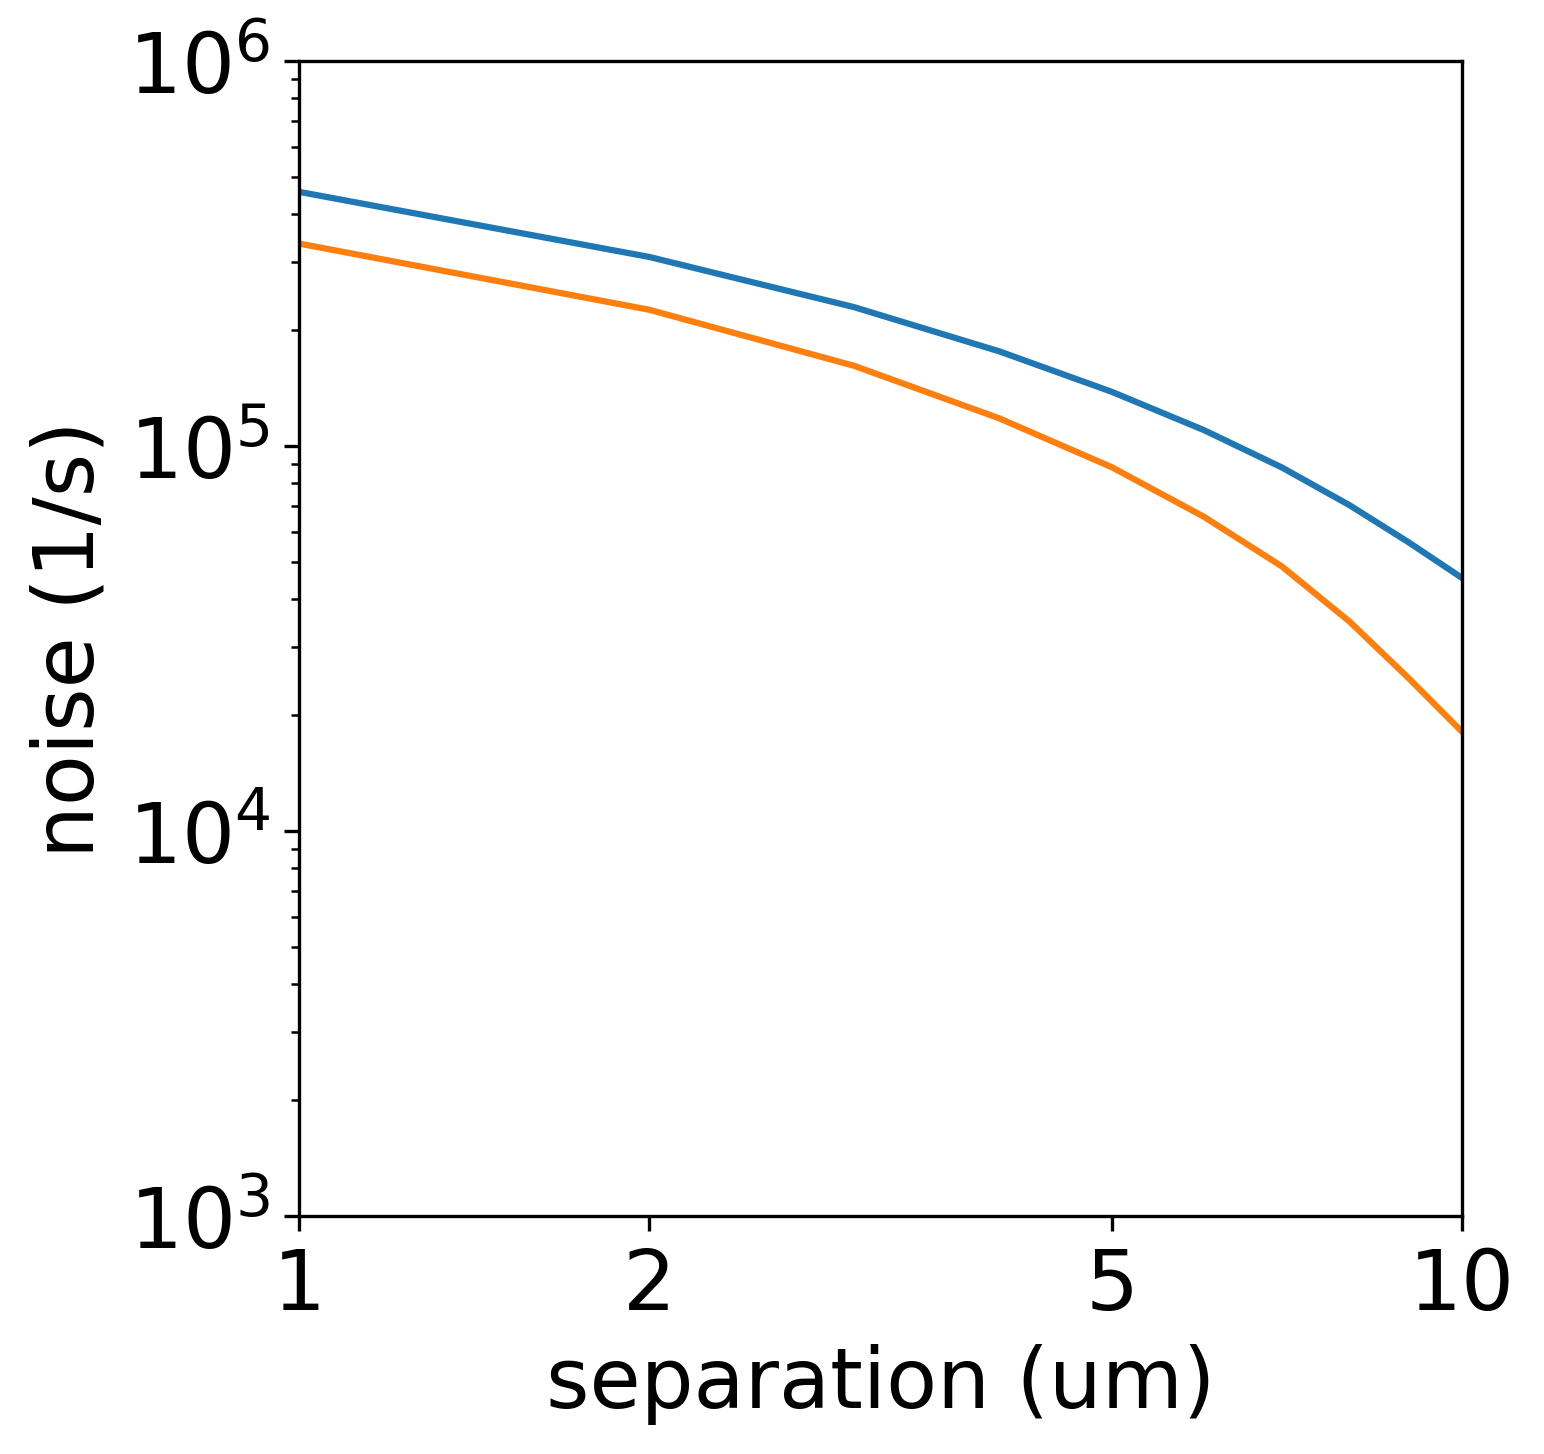

In [22]:
# Display the reproduced noise-vs-separation figure saved by the standalone script
from IPython.display import Image, display

display(Image(filename="paper_plot/noise_vs_separation.png"))

### Depth Dependence Analysis

Scan over different depth values from 1e-7 to 1e-5 and analyze how the noise varies with depth at 5 μm separation.

In [13]:
# Define depth array to scan (logarithmically spaced from 1e-7 to 1e-5)
depth_array = np.logspace(-7, -4, 20)  # 20 points from 1e-7 to 1e-5

# Initialize arrays to store noise values for different depths
pnoise_depth = []
vnoise_depth = []

print("Scanning depth values from 1e-7 to 1e-5...")

# Use the current loaded data (scoor from the single file analysis above)
# Convert scoor to Bcorr
Bcorr_base = scoor / (300*100*100) * ((phiQ/dx**2)**2)

# Parameters for noise calculation
T2 = 100e-6

# Loop through each depth value
for depth_val in depth_array:
    print(f"Processing depth = {depth_val:.2e} m")
    
    # FFT of the base correlation
    Bcorr_fft = fft.fftn(Bcorr_base, axes=(0,1))
    
    # Create k-space grids
    kx = np.roll(np.linspace(-np.pi, np.pi, Bcorr_base.shape[0]), int(Bcorr_base.shape[0]/2))
    ky = np.roll(np.linspace(-np.pi, np.pi, Bcorr_base.shape[1]), int(Bcorr_base.shape[1]/2))
    kxx, kyy = np.meshgrid(kx, ky)
    kz = np.sqrt(kxx**2 + kyy**2)
    kz_repeat = np.repeat(kz[:, :, np.newaxis], Bcorr_base.shape[2], axis=2)
    
    # Apply depth-dependent propagation
    Bcorr_fft_prop = Bcorr_fft * np.exp(-2*kz_repeat*(depth_val/dx))
    
    # Inverse FFT to get propagated correlation
    Bcorr_prop = fft.ifftn(Bcorr_fft_prop, axes=(0,1))
    
    # Compute noise arrays for this depth
    pnoise_l = []
    vnoise_l = []
    
    for i in range(50):
        pnoise_l.append(np.sum(Bcorr_prop[0,i,:])*np.exp(-i*dt/T2)*dt)
        vnoise_l.append(np.sum(Bcorr_prop[i,0,:])*np.exp(-i*dt/T2)*dt)
    
    # Store noise at separation index 5 (5 μm)
    pnoise_depth.append(gamma**2 * np.abs(pnoise_l[5]))
    vnoise_depth.append(gamma**2 * np.abs(vnoise_l[5]))

# Convert to numpy arrays
pnoise_depth = np.array(pnoise_depth)
vnoise_depth = np.array(vnoise_depth)

print("Depth scan completed!")
print(f"Depth range: {depth_array[0]:.2e} to {depth_array[-1]:.2e} m")
print(f"Noise range - pnoise: {pnoise_depth.min():.2e} to {pnoise_depth.max():.2e} (1/s)")
print(f"Noise range - vnoise: {vnoise_depth.min():.2e} to {vnoise_depth.max():.2e} (1/s)")

Scanning depth values from 1e-7 to 1e-5...
Processing depth = 1.00e-07 m
Processing depth = 1.44e-07 m
Processing depth = 2.07e-07 m
Processing depth = 2.98e-07 m
Processing depth = 4.28e-07 m
Processing depth = 6.16e-07 m
Processing depth = 8.86e-07 m
Processing depth = 1.27e-06 m
Processing depth = 1.83e-06 m
Processing depth = 2.64e-06 m
Processing depth = 3.79e-06 m
Processing depth = 5.46e-06 m
Processing depth = 7.85e-06 m
Processing depth = 1.13e-05 m
Processing depth = 1.62e-05 m
Processing depth = 2.34e-05 m
Processing depth = 3.36e-05 m
Processing depth = 4.83e-05 m
Processing depth = 6.95e-05 m
Processing depth = 1.00e-04 m
Depth scan completed!
Depth range: 1.00e-07 to 1.00e-04 m
Noise range - pnoise: 9.98e+03 to 1.38e+05 (1/s)
Noise range - vnoise: 9.88e+03 to 8.81e+04 (1/s)


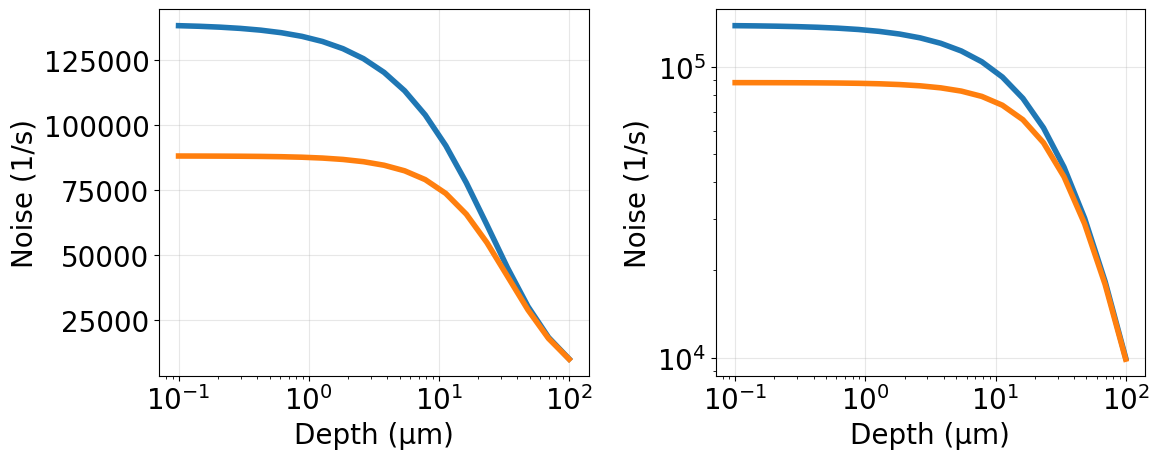


Key results:
At minimum depth (0.100 μm):
  pnoise = 1.38e+05 (1/s)
  vnoise = 8.81e+04 (1/s)
At maximum depth (100.0 μm):
  pnoise = 9.98e+03 (1/s)
  vnoise = 9.88e+03 (1/s)

Decay over 1000x depth increase:
  pnoise decreases by factor of 13.9
  vnoise decreases by factor of 8.9


In [14]:
# Plot noise as a function of depth
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 5))

# Linear scale plot
plt.subplot(1, 2, 1)
plt.semilogx(depth_array*1e6, pnoise_depth, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.semilogx(depth_array*1e6, vnoise_depth, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('Depth (μm)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs Depth (semi-log scale)')

# Log-log scale plot
plt.subplot(1, 2, 2)
plt.loglog(depth_array*1e6, pnoise_depth, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.loglog(depth_array*1e6, vnoise_depth, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('Depth (μm)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs Depth (log-log scale)')

plt.tight_layout()
plt.show()

# Print some key values
print("\nKey results:")
print(f"At minimum depth ({depth_array[0]*1e6:.3f} μm):")
print(f"  pnoise = {pnoise_depth[0]:.2e} (1/s)")
print(f"  vnoise = {vnoise_depth[0]:.2e} (1/s)")
print(f"At maximum depth ({depth_array[-1]*1e6:.1f} μm):")
print(f"  pnoise = {pnoise_depth[-1]:.2e} (1/s)")
print(f"  vnoise = {vnoise_depth[-1]:.2e} (1/s)")

# Calculate decay characteristics
depth_ratio = depth_array[-1] / depth_array[0]
pnoise_ratio = pnoise_depth[0] / pnoise_depth[-1]
vnoise_ratio = vnoise_depth[0] / vnoise_depth[-1]

print(f"\nDecay over {depth_ratio:.0f}x depth increase:")
print(f"  pnoise decreases by factor of {pnoise_ratio:.1f}")
print(f"  vnoise decreases by factor of {vnoise_ratio:.1f}")

In [23]:
# Export all data needed to reproduce the noise-vs-depth plot (cell 25)
import os

paper_plot_dir = "paper_plot"
os.makedirs(paper_plot_dir, exist_ok=True)

x_depth_um = depth_array * 1e6

np.savez(
    os.path.join(paper_plot_dir, "noise_vs_depth_data.npz"),
    x_depth_um=x_depth_um,
    pnoise_depth=np.array(pnoise_depth),
    vnoise_depth=np.array(vnoise_depth),
    xlabel=np.array("Depth (μm)"),
    ylabel=np.array("Noise (1/s)"),
    figsize=np.array([12.0, 5.0]),
    font_size=np.array(20),
)

print("Exported plot data to paper_plot/noise_vs_depth_data.npz")

Exported plot data to paper_plot/noise_vs_depth_data.npz


### T2 Dependence Analysis

Scan over different T2 values from 0.1e-6 to 100e-6 seconds and analyze how the noise varies with T2 at 5 μm separation.

In [15]:
# Define T2 array to scan (logarithmically spaced from 0.1e-6 to 100e-6 seconds)
T2_array = np.logspace(-5.5, -3, 25)  # 25 points from 0.1e-6 to 100e-6 seconds

# Initialize arrays to store noise values for different T2 values
pnoise_T2 = []
vnoise_T2 = []

print("Scanning T2 values from 0.1e-6 to 100e-6 seconds...")

# Use the current loaded data (scoor from the single file analysis above)
# Convert scoor to Bcorr and apply fixed depth propagation
Bcorr_base = scoor / (300*100*100) * ((phiQ/dx**2)**2)
depth_fixed = 1e-7  # Use a fixed depth for T2 analysis

# Apply depth propagation once
Bcorr_fft = fft.fftn(Bcorr_base, axes=(0,1))
kx = np.roll(np.linspace(-np.pi, np.pi, Bcorr_base.shape[0]), int(Bcorr_base.shape[0]/2))
ky = np.roll(np.linspace(-np.pi, np.pi, Bcorr_base.shape[1]), int(Bcorr_base.shape[1]/2))
kxx, kyy = np.meshgrid(kx, ky)
kz = np.sqrt(kxx**2 + kyy**2)
kz_repeat = np.repeat(kz[:, :, np.newaxis], Bcorr_base.shape[2], axis=2)
Bcorr_fft_prop = Bcorr_fft * np.exp(-2*kz_repeat*(depth_fixed/dx))
Bcorr_prop_base = fft.ifftn(Bcorr_fft_prop, axes=(0,1))

# Loop through each T2 value
for T2_val in T2_array:
    print(f"Processing T2 = {T2_val*1e6:.2f} μs")
    
    # Compute noise arrays for this T2
    pnoise_l = []
    vnoise_l = []
    
    for i in range(50):
        pnoise_l.append(np.sum(Bcorr_prop_base[0,i,:])*np.exp(-i*dt/T2_val)*dt)
        vnoise_l.append(np.sum(Bcorr_prop_base[i,0,:])*np.exp(-i*dt/T2_val)*dt)
    
    # Store noise at separation index 5 (5 μm)
    pnoise_T2.append(gamma**2 * np.abs(pnoise_l[5]))
    vnoise_T2.append(gamma**2 * np.abs(vnoise_l[5]))

# Convert to numpy arrays
pnoise_T2 = np.array(pnoise_T2)
vnoise_T2 = np.array(vnoise_T2)

print("T2 scan completed!")
print(f"T2 range: {T2_array[0]*1e6:.2f} to {T2_array[-1]*1e6:.1f} μs")
print(f"Noise range - pnoise: {pnoise_T2.min():.2e} to {pnoise_T2.max():.2e} (1/s)")
print(f"Noise range - vnoise: {vnoise_T2.min():.2e} to {vnoise_T2.max():.2e} (1/s)")

Scanning T2 values from 0.1e-6 to 100e-6 seconds...
Processing T2 = 3.16 μs
Processing T2 = 4.02 μs
Processing T2 = 5.11 μs
Processing T2 = 6.49 μs
Processing T2 = 8.25 μs
Processing T2 = 10.49 μs
Processing T2 = 13.34 μs
Processing T2 = 16.95 μs
Processing T2 = 21.54 μs
Processing T2 = 27.38 μs
Processing T2 = 34.81 μs
Processing T2 = 44.24 μs
Processing T2 = 56.23 μs
Processing T2 = 71.48 μs
Processing T2 = 90.85 μs
Processing T2 = 115.48 μs
Processing T2 = 146.78 μs
Processing T2 = 186.57 μs
Processing T2 = 237.14 μs
Processing T2 = 301.42 μs
Processing T2 = 383.12 μs
Processing T2 = 486.97 μs
Processing T2 = 618.97 μs
Processing T2 = 786.74 μs
Processing T2 = 1000.00 μs
T2 scan completed!
T2 range: 3.16 to 1000.0 μs
Noise range - pnoise: 5.17e+02 to 1.63e+05 (1/s)
Noise range - vnoise: 3.30e+02 to 1.04e+05 (1/s)


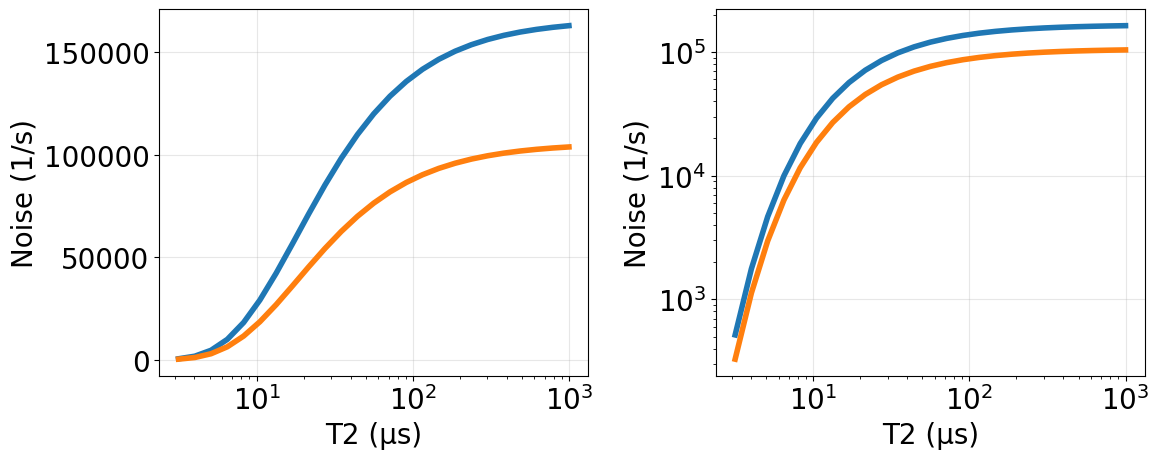


Key results:
At minimum T2 (3.16 μs):
  pnoise = 5.17e+02 (1/s)
  vnoise = 3.30e+02 (1/s)
At maximum T2 (1000.0 μs):
  pnoise = 1.63e+05 (1/s)
  vnoise = 1.04e+05 (1/s)

Scaling over 316x T2 increase:
  pnoise increases by factor of 315.1
  vnoise increases by factor of 315.1

Maximum sensitivity:
  pnoise: T2 = 3.2 μs
  vnoise: T2 = 3.2 μs


In [16]:
# Plot noise as a function of T2
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 5))

# Linear scale plot
plt.subplot(1, 2, 1)
plt.semilogx(T2_array*1e6, pnoise_T2, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.semilogx(T2_array*1e6, vnoise_T2, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('T2 (μs)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs T2 (semi-log scale)')

# Log-log scale plot
plt.subplot(1, 2, 2)
plt.loglog(T2_array*1e6, pnoise_T2, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.loglog(T2_array*1e6, vnoise_T2, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('T2 (μs)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs T2 (log-log scale)')

plt.tight_layout()
plt.show()

# Print some key values
print("\nKey results:")
print(f"At minimum T2 ({T2_array[0]*1e6:.2f} μs):")
print(f"  pnoise = {pnoise_T2[0]:.2e} (1/s)")
print(f"  vnoise = {vnoise_T2[0]:.2e} (1/s)")
print(f"At maximum T2 ({T2_array[-1]*1e6:.1f} μs):")
print(f"  pnoise = {pnoise_T2[-1]:.2e} (1/s)")
print(f"  vnoise = {vnoise_T2[-1]:.2e} (1/s)")

# Calculate scaling characteristics
T2_ratio = T2_array[-1] / T2_array[0]
pnoise_ratio = pnoise_T2[-1] / pnoise_T2[0]
vnoise_ratio = vnoise_T2[-1] / vnoise_T2[0]

print(f"\nScaling over {T2_ratio:.0f}x T2 increase:")
print(f"  pnoise increases by factor of {pnoise_ratio:.1f}")
print(f"  vnoise increases by factor of {vnoise_ratio:.1f}")

# Find T2 value that gives maximum noise sensitivity (derivative)
T2_log = np.log10(T2_array)
pnoise_log = np.log10(pnoise_T2)
vnoise_log = np.log10(vnoise_T2)

# Calculate numerical derivative
dpnoise_dT2 = np.gradient(pnoise_log, T2_log)
dvnoise_dT2 = np.gradient(vnoise_log, T2_log)

max_sensitivity_idx_p = np.argmax(np.abs(dpnoise_dT2))
max_sensitivity_idx_v = np.argmax(np.abs(dvnoise_dT2))

print(f"\nMaximum sensitivity:")
print(f"  pnoise: T2 = {T2_array[max_sensitivity_idx_p]*1e6:.1f} μs")
print(f"  vnoise: T2 = {T2_array[max_sensitivity_idx_v]*1e6:.1f} μs")

In [24]:
# Export all data needed to reproduce the noise-vs-T2 plot (cell 28)
import os

paper_plot_dir = "paper_plot"
os.makedirs(paper_plot_dir, exist_ok=True)

x_T2_us = T2_array * 1e6

np.savez(
    os.path.join(paper_plot_dir, "noise_vs_T2_data.npz"),
    x_T2_us=x_T2_us,
    pnoise_T2=np.array(pnoise_T2),
    vnoise_T2=np.array(vnoise_T2),
    xlabel=np.array("T2 (μs)"),
    ylabel=np.array("Noise (1/s)"),
    figsize=np.array([12.0, 5.0]),
    font_size=np.array(20),
)

print("Exported plot data to paper_plot/noise_vs_T2_data.npz")

Exported plot data to paper_plot/noise_vs_T2_data.npz


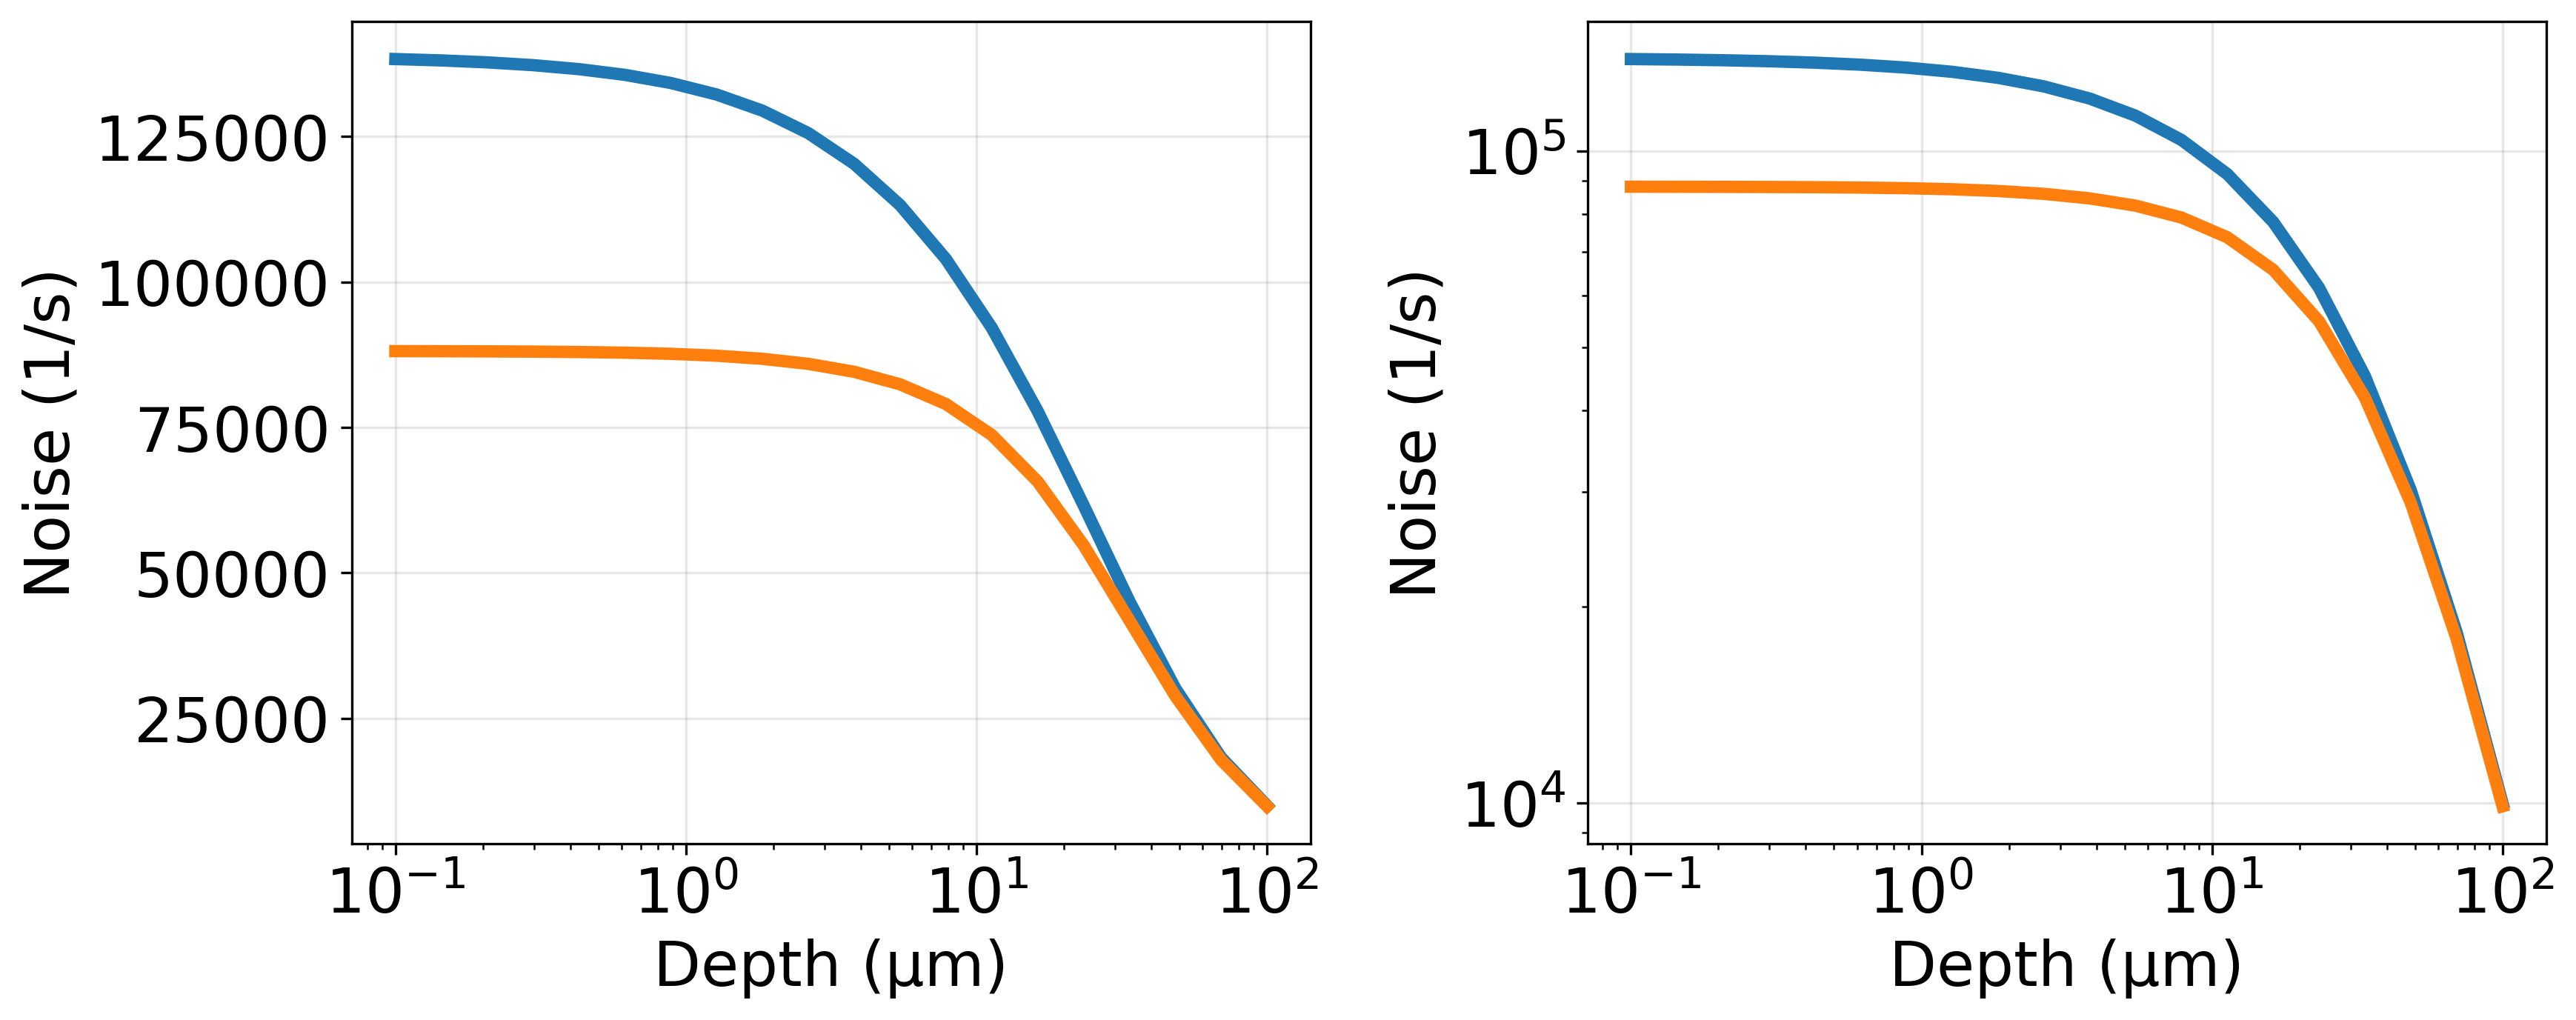

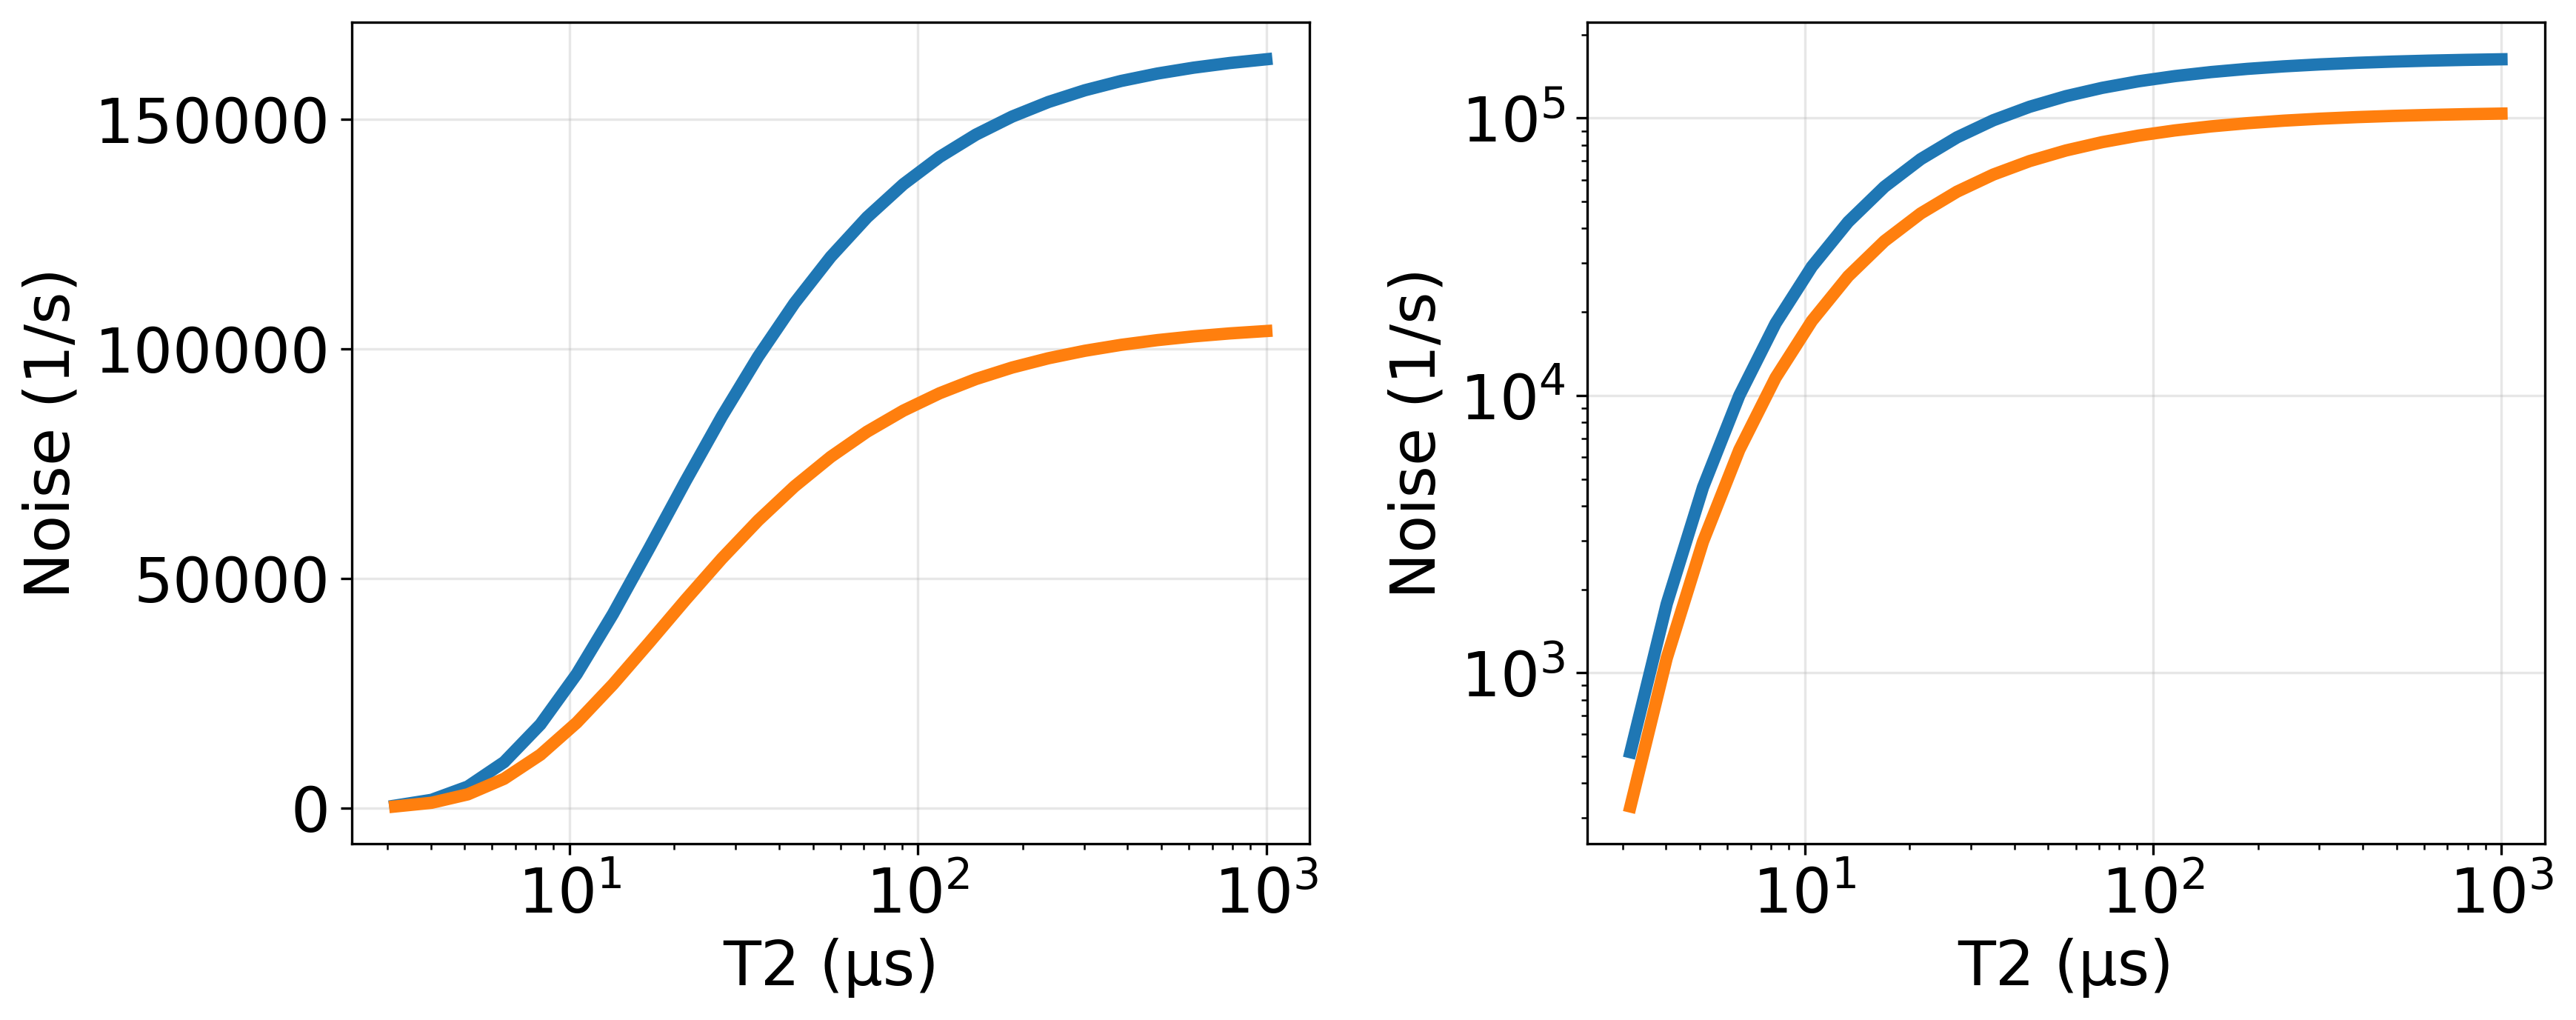

In [25]:
# Display reproduced noise-vs-depth and noise-vs-T2 figures
from IPython.display import Image, display

display(Image(filename="paper_plot/noise_vs_depth.png"))
display(Image(filename="paper_plot/noise_vs_T2.png"))

## Noise Analysis Across Je Parameter Sweep

Load all data files and compute pnoise_l and vnoise_l for each Je value, then plot the noise at separation index 10.

In [17]:
Je_array = [0.01, 0.0221, 0.0304, 0.0418, 0.0489, 0.0574, 0.0672, 0.0788, 0.0924, 0.108]
idx_start = 21  # Starting index for file IDs

# Initialize lists to store noise values for all Je values
all_pnoise_l = []
all_vnoise_l = []

# Loop through all Je values (assuming file IDs start from 1)
for idx, Je_val in enumerate(Je_array):
    file_id = idx + idx_start  # File IDs start from idx_start
    file_name = f"../data/250629/250629_{file_id}_"
    
    print(f"Processing file {file_id} for Je = {Je_val}")
    
    try:
        # Load data for this Je value
        x_l = np.loadtxt(file_name+'pcoor_scanx.csv', skiprows=1)
        y_l = np.loadtxt(file_name+'pcoor_scany.csv', skiprows=1)
        t_l = np.loadtxt(file_name+'pcoor_scanz.csv', skiprows=1)
        raw = np.loadtxt(file_name+'scoor_data.csv', skiprows=1, delimiter=',')
        scoor = raw.reshape((len(x_l), len(y_l), len(t_l)), order='F')
        
        # Compute Bcorr for this dataset
        Bcorr = scoor / (300*100*100) * ((phiQ/dx**2)**2)
        
        # FFT and propagation
        Bcorr_fft = fft.fftn(Bcorr, axes=(0,1))
        
        kx = np.roll(np.linspace(-np.pi, np.pi, Bcorr.shape[0]), int(Bcorr.shape[0]/2))
        ky = np.roll(np.linspace(-np.pi, np.pi, Bcorr.shape[1]), int(Bcorr.shape[1]/2))
        kxx, kyy = np.meshgrid(kx, ky)
        kz = np.sqrt(kxx**2 + kyy**2)
        kz_repeat = np.repeat(kz[:, :, np.newaxis], Bcorr.shape[2], axis=2)
        Bcorr_fft_prop = Bcorr_fft * np.exp(-2*kz_repeat*(depth/dx))
        
        Bcorr_prop = fft.ifftn(Bcorr_fft_prop, axes=(0,1))
        
        # Compute noise arrays
        pnoise_l = []
        vnoise_l = []
        
        for i in range(50):
            pnoise_l.append(np.sum(Bcorr_prop[0,i,:])*np.exp(-i*dt/T2)*dt)
            vnoise_l.append(np.sum(Bcorr_prop[i,0,:])*np.exp(-i*dt/T2)*dt)
        
        # Store the noise arrays for this Je value
        all_pnoise_l.append(pnoise_l)
        all_vnoise_l.append(vnoise_l)
        
    except Exception as e:
        print(f"Error loading file {file_id}: {e}")
        # Append None or zeros if file doesn't exist
        all_pnoise_l.append([0]*50)
        all_vnoise_l.append([0]*50)

# Convert to numpy arrays for easier manipulation
all_pnoise_l = np.array(all_pnoise_l)
all_vnoise_l = np.array(all_vnoise_l)

print(f"Loaded data for {len(all_pnoise_l)} Je values")
print(f"Shape of all_pnoise_l: {all_pnoise_l.shape}")
print(f"Shape of all_vnoise_l: {all_vnoise_l.shape}")

Processing file 21 for Je = 0.01
Processing file 22 for Je = 0.0221
Processing file 23 for Je = 0.0304
Processing file 24 for Je = 0.0418
Processing file 25 for Je = 0.0489
Processing file 26 for Je = 0.0574
Processing file 27 for Je = 0.0672
Processing file 28 for Je = 0.0788
Processing file 29 for Je = 0.0924
Processing file 30 for Je = 0.108
Loaded data for 10 Je values
Shape of all_pnoise_l: (10, 50)
Shape of all_vnoise_l: (10, 50)


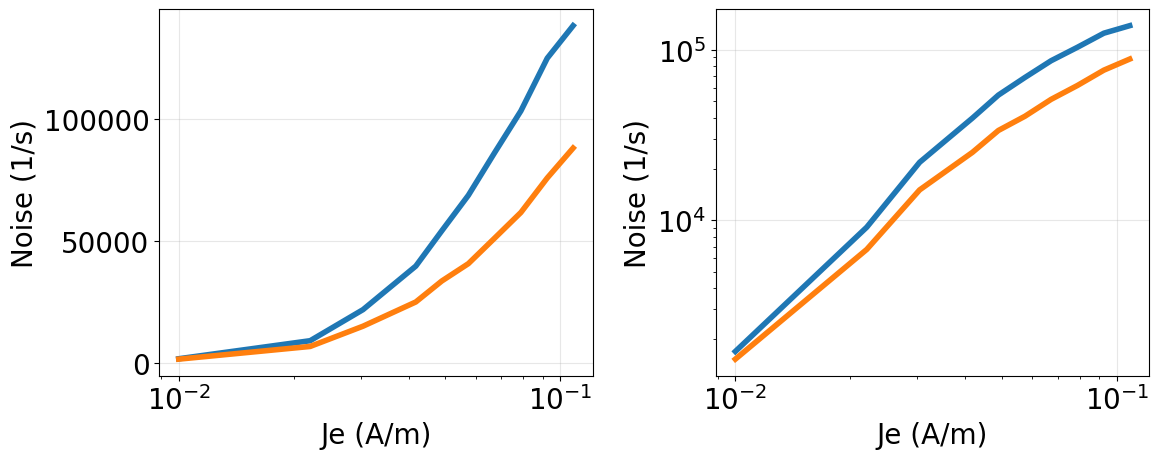

Je values: [0.01, 0.0221, 0.0304, 0.0418, 0.0489, 0.0574, 0.0672, 0.0788, 0.0924, 0.108]


NameError: name 'pnoise_10' is not defined

In [18]:
# Extract noise values at separation index 5 (corresponding to 5 μm separation)
pnoise_5 = gamma**2 * np.abs(all_pnoise_l[:, 5])
vnoise_5 = gamma**2 * np.abs(all_vnoise_l[:, 5])

# Create the plot
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(Je_array, pnoise_5, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.semilogx(Je_array, vnoise_5, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('Je (A/m)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs Je at 100 μm separation')

plt.subplot(1, 2, 2)
plt.loglog(Je_array, pnoise_5, '-', linewidth=4, markersize=8, label='pnoise (parallel)')
plt.loglog(Je_array, vnoise_5, '-', linewidth=4, markersize=8, label='vnoise (perpendicular)')
plt.xlabel('Je (A/m)')
plt.ylabel('Noise (1/s)')
# plt.legend()
plt.grid(True, alpha=0.3)
# plt.title('Noise vs Je (log-log scale)')

plt.tight_layout()
plt.show()

# Print the values for reference
print("Je values:", Je_array)
print("pnoise_10:", pnoise_10)
print("vnoise_10:", vnoise_10)

In [ ]:
# Fit power law scaling to understand the Je dependence
# Filter out zero values for fitting
valid_indices = (pnoise_10 > 0) & (vnoise_10 > 0)
Je_valid = np.array(Je_array)[valid_indices]
pnoise_valid = pnoise_10[valid_indices]
vnoise_valid = vnoise_10[valid_indices]

if len(Je_valid) > 2:  # Need at least 3 points for meaningful fit
    # Fit power law: noise = A * Je^alpha
    log_Je = np.log10(Je_valid)
    log_pnoise = np.log10(pnoise_valid)
    log_vnoise = np.log10(vnoise_valid)
    
    # Linear fit in log space
    p_coeffs = np.polyfit(log_Je, log_pnoise, 1)
    v_coeffs = np.polyfit(log_Je, log_vnoise, 1)
    
    alpha_p = p_coeffs[0]  # Power law exponent for pnoise
    A_p = 10**p_coeffs[1]  # Prefactor for pnoise
    alpha_v = v_coeffs[0]  # Power law exponent for vnoise
    A_v = 10**v_coeffs[1]  # Prefactor for vnoise
    
    print(f"pnoise scaling: noise ∝ Je^{alpha_p:.2f}")
    print(f"vnoise scaling: noise ∝ Je^{alpha_v:.2f}")
    
    # Plot with fitted curves
    plt.figure(figsize=(8, 6))
    Je_fit = np.logspace(np.log10(min(Je_valid)), np.log10(max(Je_valid)), 100)
    pnoise_fit = A_p * Je_fit**alpha_p
    vnoise_fit = A_v * Je_fit**alpha_v
    
    plt.loglog(Je_array, pnoise_10, 'o', markersize=8, label='pnoise (parallel)')
    plt.loglog(Je_array, vnoise_10, 's', markersize=8, label='vnoise (perpendicular)')
    plt.loglog(Je_fit, pnoise_fit, '--', alpha=0.7, label=f'pnoise fit: ∝ Je^{alpha_p:.2f}')
    plt.loglog(Je_fit, vnoise_fit, '--', alpha=0.7, label=f'vnoise fit: ∝ Je^{alpha_v:.2f}')
    
    plt.xlabel('Je (A/m)')
    plt.ylabel('Noise at 100 μm (1/s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Noise vs Je with Power Law Fits')
    plt.show()
else:
    print("Not enough valid data points for power law fitting")